# Inlämningsuppgift – Klassificera ansiktsuttryck med neurala nätverk

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.optimizers import Adam

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1) Förstå datan

In [2]:
# Laddar in datan

train_folder = "data/FER-2013/train"
test_folder = "data/FER-2013/test"

class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

def load_fer2013_data(folder, class_names):
    images = []
    labels = []

    for label, class_name in enumerate(class_names):
        class_folder = folder + "/" + class_name

        for image_name in os.listdir(class_folder):
            image_file = class_folder + "/" + image_name

            image = load_img(
                image_file,
                color_mode="grayscale",
                target_size=(48, 48)
            )

            image = img_to_array(image)
            image = image.squeeze()

            images.append(image)
            labels.append(label)

    images = np.array(images)
    labels = np.array(labels)

    return images, labels


train_images_full, train_labels_full = load_fer2013_data(train_folder, class_names)
test_images, test_labels = load_fer2013_data(test_folder, class_names)

In [3]:
print("Bilder i train set:", train_images_full.shape)
print("Bilder i test set:", test_images.shape)
print("Bilder totalt:", len(train_labels_full) + len(test_labels))
print("Klasser:", np.unique(test_labels))

Bilder i train set: (28709, 48, 48)
Bilder i test set: (7178, 48, 48)
Bilder totalt: 35887
Klasser: [0 1 2 3 4 5 6]


### Summering av dataset

- Datasetet innehåller 35,887 bilder där varje bild representeras i 48 x 48 pixels var.
- Datasetet är indelat i train-set - 28,709 bilder och test-set - 7,178. 
- Det finns 7 klasskategorier eller *labels* som bilderna kan hamna inom - *labels* är en vektor av integers från 0 till 6. Dessa representerar vilken sort av ansiktsuttryck bilder hamnar inom:

| Label       | Class       |
| ----------- | ----------- |
| 0 	      |  angry      |
| 1 	      |  disgust    |
| 2 	      |  fear       |
| 3 	      |  happy      |
| 4 	      |  neutral    |
| 5 	      |  sad        |
| 6 	      |  surprise   |

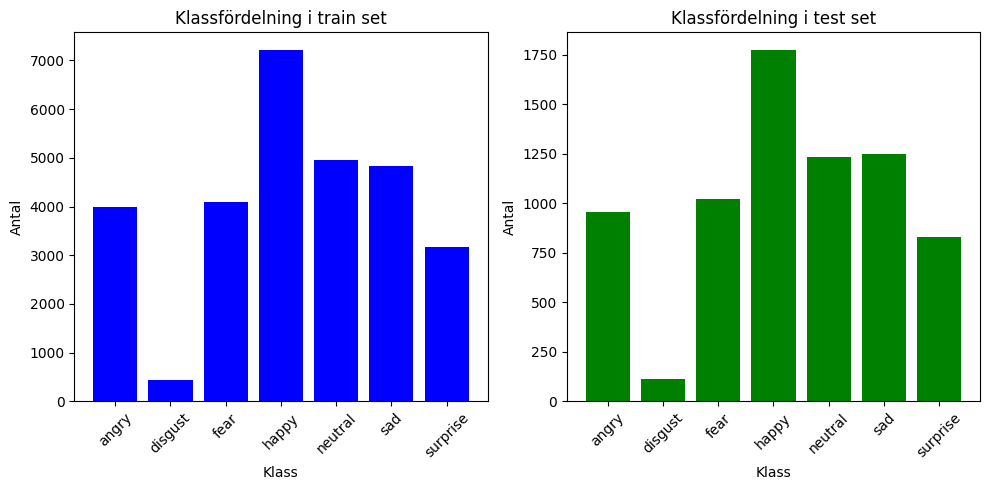

In [4]:
# Identifierar eventuella obalanser

classes_train, counts_train = np.unique(train_labels_full, return_counts=True)
classes_test, counts_test = np.unique(test_labels, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(classes_train, counts_train, color='blue')
axes[0].set_title('Klassfördelning i train set')
axes[0].set_xlabel('Klass')
axes[0].set_ylabel('Antal')
axes[0].set_xticks(classes_train)
axes[0].set_xticklabels(class_names, rotation=45)

axes[1].bar(classes_test, counts_test, color='green')
axes[1].set_title('Klassfördelning i test set')
axes[1].set_xlabel('Klass')
axes[1].set_ylabel('Antal')
axes[1].set_xticks(classes_test)
axes[1].set_xticklabels(class_names, rotation=45)

plt.tight_layout()
plt.show()

Datasetet är **obalanserat**, där vissa klasser förekommer betydligt oftare än andra. För att minska träningstiden och göra klassfördelningen jämnare skapar jag därför ett balanserat subset med lika många bilder från varje klass längre fram i projektet.

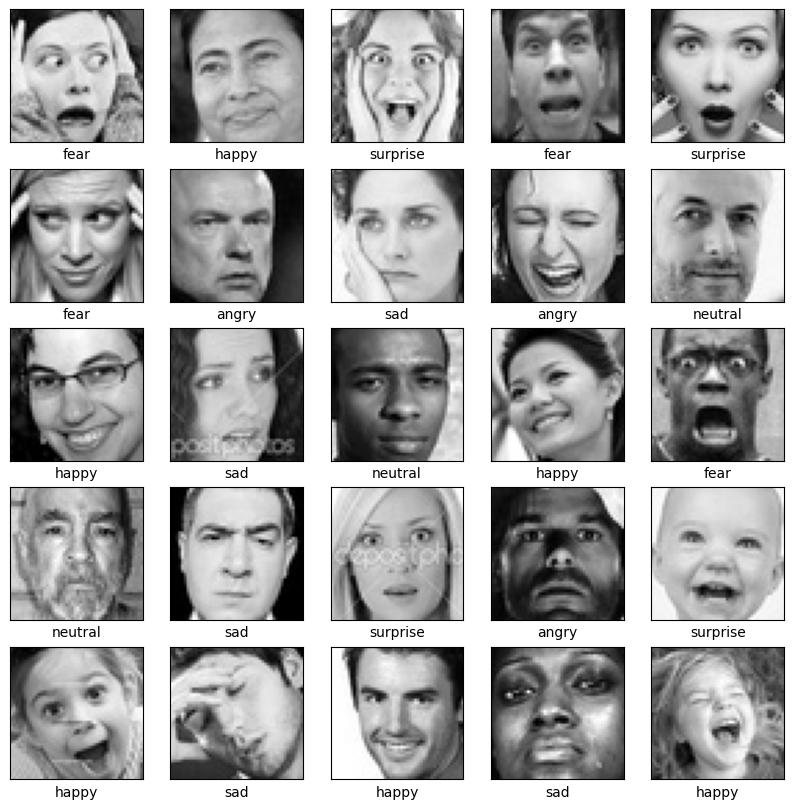

In [5]:
# Visar exempelbilder från träningsdatan

plt.figure(figsize=(10,10))

random_pictures = np.random.choice(len(train_images_full), size=25, replace=False)

for i, index in enumerate(random_pictures):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images_full[index], cmap="gray")
    plt.xlabel(class_names[train_labels_full[index]])

plt.show()

## 2) Förbereda datan

In [6]:
def create_balanced_subset(X, y, samples_per_class=400, random_state=42):

    rng = np.random.default_rng(random_state)
    selected_indices = []

    for class_id in np.unique(y):
        class_indices = np.where(y == class_id)[0]

        if len(class_indices) < samples_per_class:
            raise ValueError(
                f"Klassen {class_id} har bara {len(class_indices)} exempel, "
                f"men samples_per_class={samples_per_class}"
            )
        
        chosen_indices = rng.choice(
            class_indices,
            size=samples_per_class,
            replace=False
        )

        selected_indices.extend(chosen_indices)
    
    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    return X[selected_indices], y[selected_indices]


X_subset_raw, y_subset = create_balanced_subset(
    train_images_full,
    train_labels_full,
    samples_per_class=400,
    random_state=42
)

print("X_subset_raw:", X_subset_raw.shape)
print("y_subset:", y_subset.shape)

X_subset_raw: (2800, 48, 48)
y_subset: (2800,)


För att minska träningstiden använder jag ett balanserat subset av träningsdatan med 400 bilder per klass. Testdatan behölls däremot i sin helhet för att modellen skulle kunna utvärderas på hela testmängden.

In [7]:
train_images, val_images, train_labels, val_labels = train_test_split(
    X_subset_raw,
    y_subset,
    test_size=0.20,
    random_state=42,
    stratify=y_subset
)

print("Train images:", train_images.shape)
print("Validation images:", val_images.shape)
print("Train labels:", train_labels.shape)
print("Validatio labels:", val_labels.shape)

Train images: (2240, 48, 48)
Validation images: (560, 48, 48)
Train labels: (2240,)
Validatio labels: (560,)


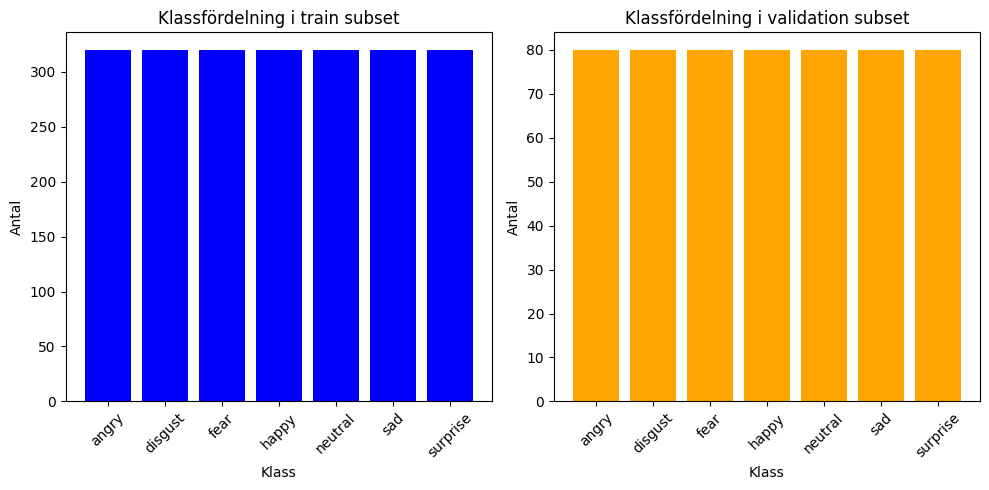

In [8]:
# Kontrolerar klassfördelning efter min split:

classes_train, counts_train = np.unique(train_labels, return_counts=True)
classes_val, counts_val = np.unique(val_labels, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(classes_train, counts_train, color='blue')
axes[0].set_title('Klassfördelning i train subset')
axes[0].set_xlabel('Klass')
axes[0].set_ylabel('Antal')
axes[0].set_xticks(classes_train)
axes[0].set_xticklabels(class_names, rotation=45)

axes[1].bar(classes_val, counts_val, color='orange')
axes[1].set_title('Klassfördelning i validation subset')
axes[1].set_xlabel('Klass')
axes[1].set_ylabel('Antal')
axes[1].set_xticks(classes_val)
axes[1].set_xticklabels(class_names, rotation=45)

plt.tight_layout()
plt.show()

In [9]:
# Normaliserar bilderna

train_images_norm = train_images / 255.0
val_images_norm = val_images / 255.0
test_images_norm = test_images / 255.0

print("Train imgs min/max:", train_images_norm.min(), train_images_norm.max())
print("Validation imgs min/max:", val_images_norm.min(), val_images_norm.max())
print("Test imgs shape:", test_images_norm.shape)

Train imgs min/max: 0.0 1.0
Validation imgs min/max: 0.0 1.0
Test imgs shape: (7178, 48, 48)


In [10]:
# Anpassar bildformatet för CNN

train_images_norm = train_images_norm[..., np.newaxis]
val_images_norm = val_images_norm[..., np.newaxis]
test_images_norm = test_images_norm[..., np.newaxis]

print("Train imgs shape efter kanal-dimension:", train_images_norm.shape)
print("Validation imgs shape efter kanal-dimension:", val_images_norm.shape)
print("Test imgs shape efter kanal-dimension:", test_images_norm.shape)

Train imgs shape efter kanal-dimension: (2240, 48, 48, 1)
Validation imgs shape efter kanal-dimension: (560, 48, 48, 1)
Test imgs shape efter kanal-dimension: (7178, 48, 48, 1)


## 3) Bygger en modell

In [11]:
# Bygger en baseline CNN-model

def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(48, 48, 1)),

        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(64, activation="relu"),       # 64 neuroner 
        layers.Dense(7, activation="softmax")      # 7 klassser
    ])
    
    model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
    )
    
    return model

In [12]:
baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609,159 (2.32 MB)

 Trainable params: 609,159 (2.32 MB)

 Non-trainable params: 0 (0.00 B)

Skapade en baseline-modell med CNN-arkitektur. Modellen består av två convolutional layers (Conv2D) som används för att identifiera mönster i bilderna, följt av max pooling som minskar bilddimensionerna. Därefter används ett flatten-lager och dense-lager för klassificering. Det sista lagret har 7 neuroner eftersom datasetet innehåller 7 klasser. Softmax används för att modellen ska ge sannolikheter för varje klass.

## 4) Träna modellen

### Träna baseline-modellen

Efter att baseline-modellen har byggts och compile:ats tränas den på normaliserade träningsdata. 
Jag använder validation data för att kunna följa hur modellen presterar på data som den inte tränas direkt på.

I den första baseline använder jag 5 epochs och batch size 32. 
Resultatet sparas i `history_baseline`, vilket gör att man senare kan visualisera utvecklingen av loss och accuracy under träningen.

In [13]:
start_time = time.time()

history_baseline = baseline_model.fit(
    train_images_norm,
    train_labels,
    validation_data = (val_images_norm, val_labels),
    epochs=5,
    batch_size=32
)

baseline_trainig_time = time.time() - start_time

print(f"Träningstid för baseline på subset: {baseline_trainig_time / 60:.2f} minuter")

Epoch 1/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.1589 - loss: 1.9505 - val_accuracy: 0.1446 - val_loss: 1.9417
Epoch 2/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.2018 - loss: 1.9122 - val_accuracy: 0.2482 - val_loss: 1.8640
Epoch 3/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.2964 - loss: 1.7939 - val_accuracy: 0.2732 - val_loss: 1.8289
Epoch 4/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.3594 - loss: 1.6898 - val_accuracy: 0.2964 - val_loss: 1.8005
Epoch 5/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.4121 - loss: 1.5876 - val_accuracy: 0.3357 - val_loss: 1.7753
Träningstid för baseline på subset: 0.29 minuter


In [14]:
# Funktion för att plotta träningskurvor för loss och accuracy.

def plot_history(history, title="Träningskurvor"):
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Traning loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.grid(True)
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Traning accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.grid(True)
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

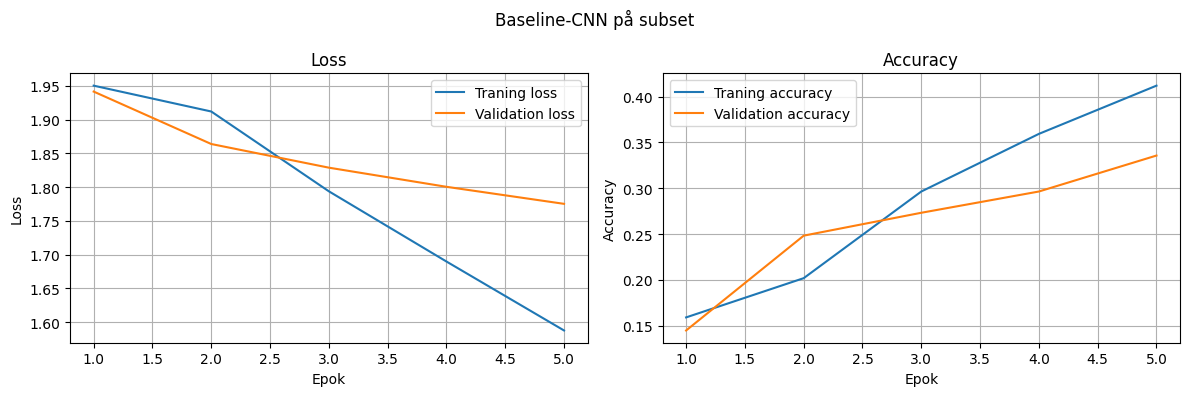

In [15]:
plot_history(history_baseline, title="Baseline-CNN på subset")

Modellen förbättras under träningen, då **training accuracy ökar och training loss minskar**. Även validation accuracy ökar, vilket visar att modellen lär sig mönster som delvis fungerar på ny data. 
Samtidigt ser jag att validation accuracy är lägre än training accuracy, vilket tyder på att modellen har svårare att generalisera och att det finns vissa **tecken på overfitting**. Eftersom detta är en enkel baseline-modell tränad på ett mindre subset är resultatet ändå en rimlig såhär i början.

## 5) Utvärdera modellen

In [16]:
def predict_classes(model, X):
    y_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    return y_pred, y_proba

In [17]:
baseline_val_pred, baseline_val_proba = predict_classes(
    baseline_model,
    val_images_norm
)

baseline_val_accuracy = accuracy_score(val_labels, baseline_val_pred)

print(f"Baseline validation accuracy: {baseline_val_accuracy:.4f}")

Baseline validation accuracy: 0.3357


In [18]:
history_baseline_df = pd.DataFrame(history_baseline.history)

best_epoch = history_baseline_df["val_loss"].idxmin() + 1
best_val_loss = history_baseline_df["val_loss"].min()
best_val_accuracy = history_baseline_df["val_accuracy"].iloc[best_epoch - 1]

print(f"Bästa validation loss vid epok: {best_epoch}")
print(f"Bästa validation loss: {best_val_loss:.4f}")
print(f"Validation accuracy vid den epoken: {best_val_accuracy:.4f}")

Bästa validation loss vid epok: 5
Bästa validation loss: 1.7753
Validation accuracy vid den epoken: 0.3357


In [19]:
# Plot för confusionmatrix

def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion matrix"):

    labels = np.arange(len(class_names))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    fig, ax = plt.subplots(figsize=(12, 10))

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    display.plot(
        ax=ax,
        xticks_rotation=45,
        values_format="d",
        cmap="Oranges",
        colorbar=False
    )

    ax.set_xlabel("Predicted label", fontsize=14)
    ax.set_ylabel("True label", fontsize=14)

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return cm

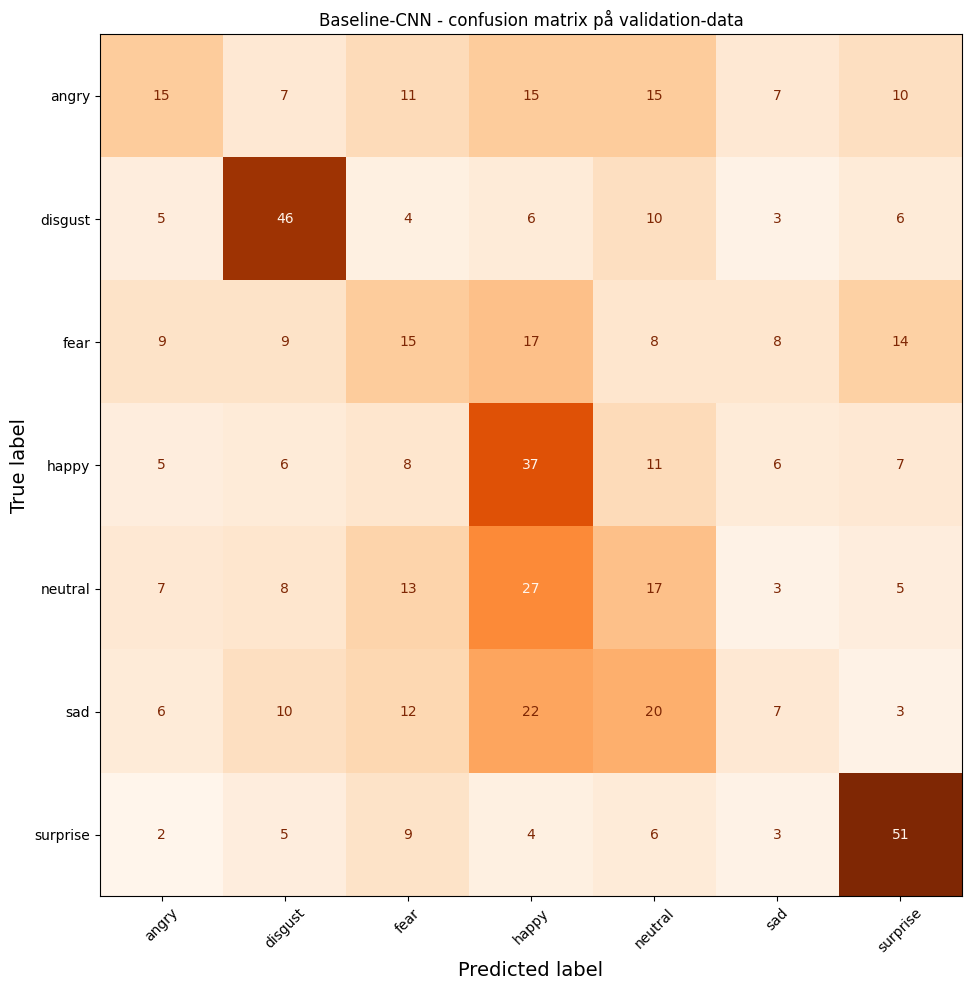

In [20]:
baseline_cm = plot_confusion_matrix(
    val_labels,
    baseline_val_pred,
    class_names,
    title="Baseline-CNN - confusion matrix på validation-data"
)

Confusion matrixen visar att modellen klassificerar `surprise` och `disgust` bäst, med **51 respektive 46 korrekta prediktioner av 80**. Klassen `happy` fungerar också något bättre än flera andra klasser. Däremot har modellen **svårt att skilja mellan** `angry`, `fear`, `neutral` och `sad`, som ofta blandas ihop med andra uttryck. Detta visar att modellen har lärt sig vissa tydliga mönster, men att den fortfarande har svårt att separera mer lika eller subtila ansiktsuttryck.

### Felanalys

In [21]:
# Hjälpfunktion: Accuracy per klass

def calculate_per_classs_accuracy(cm, class_names):

    support = cm.sum(axis=1)
    korrekta = np.diag(cm)

    accuracy = np.divide(
        korrekta,
        support,
        out=np.zeros_like(korrekta, dtype=float),
        where=support != 0
    )

    result = pd.DataFrame({
        "class_id": np.arange(len(class_names)),
        "class_name": class_names,
        "support": support,
        "correct": korrekta,
        "accuracy": accuracy
    })

    return result.sort_values("accuracy")

In [22]:
baseline_per_class = calculate_per_classs_accuracy(
    baseline_cm,
    class_names
)

baseline_per_class

,class_id,class_name,support,correct,accuracy
5,5,sad,80,7,0.0875
0,0,angry,80,15,0.1875
2,2,fear,80,15,0.1875
4,4,neutral,80,17,0.2125
3,3,happy,80,37,0.4625
1,1,disgust,80,46,0.5750
6,6,surprise,80,51,0.6375


Tabellen visar att modellens resultat varierar mycket mellan klasserna. `Surprise` och `disgust` **klassificeras bäst**, med accuracy på cirka 0.64 respektive 0.58. Klassen `happy` fungerar också bättre än flera andra klasser. Däremot har modellen **svårt med framför allt** `sad`, `angry` och `fear`, där accuracy är låg. Detta tyder på att baseline-modellen har lättare att känna igen tydligare uttryck men svårare att skilja mellan mer lika eller subtila ansiktsuttryck.

In [25]:
# Hjälpfunktion: Bildexempel på vanligaste förväxlingarna 

def plot_misclassified_examples(
    X,
    y_true,
    y_pred,
    y_proba,
    class_names,
    n_images=18,
    random_state=42
):
    """
    Visar felklassificerade bilder.

    X:
        Bilddata, normaliserad eller i 0-1-format.

    y_true:
        Sanna labels.

    y_pred:
        Predikterade labels.

    y_proba:
        Sannolikheter från modellen.

    class_names:
        Lista med klassnamn.

    n_images:
        Antal felklassificerade bilder att visa.

    random_state:
        Seed för reproducerbart urval.
    """

    error_indices = np.where(y_true != y_pred)[0]

    print(f"Totalt antal felklassificerade bilder: {len(error_indices)}")

    if len(error_indices) == 0:
        print("Inga felklassificerade bilder att visa.")
        return

    rng = np.random.default_rng(random_state)

    chosen_indices = rng.choice(
        error_indices,
        size=min(n_images, len(error_indices)),
        replace=False
    )

    cols = 6
    rows = int(np.ceil(len(chosen_indices) / cols))

    plt.figure(figsize=(14, 4 * rows))

    for plot_index, data_index in enumerate(chosen_indices):
        true_label = y_true[data_index]
        pred_label = y_pred[data_index]
        confidence = y_proba[data_index, pred_label] * 100

        plt.subplot(rows, cols, plot_index + 1)
        plt.imshow(X[data_index].squeeze(), cmap="gray")
        plt.title(
            f"Sann: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]}\n"
            f"Säkerhet: {confidence:.1f}%",
            fontsize=9
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Totalt antal felklassificerade bilder: 372


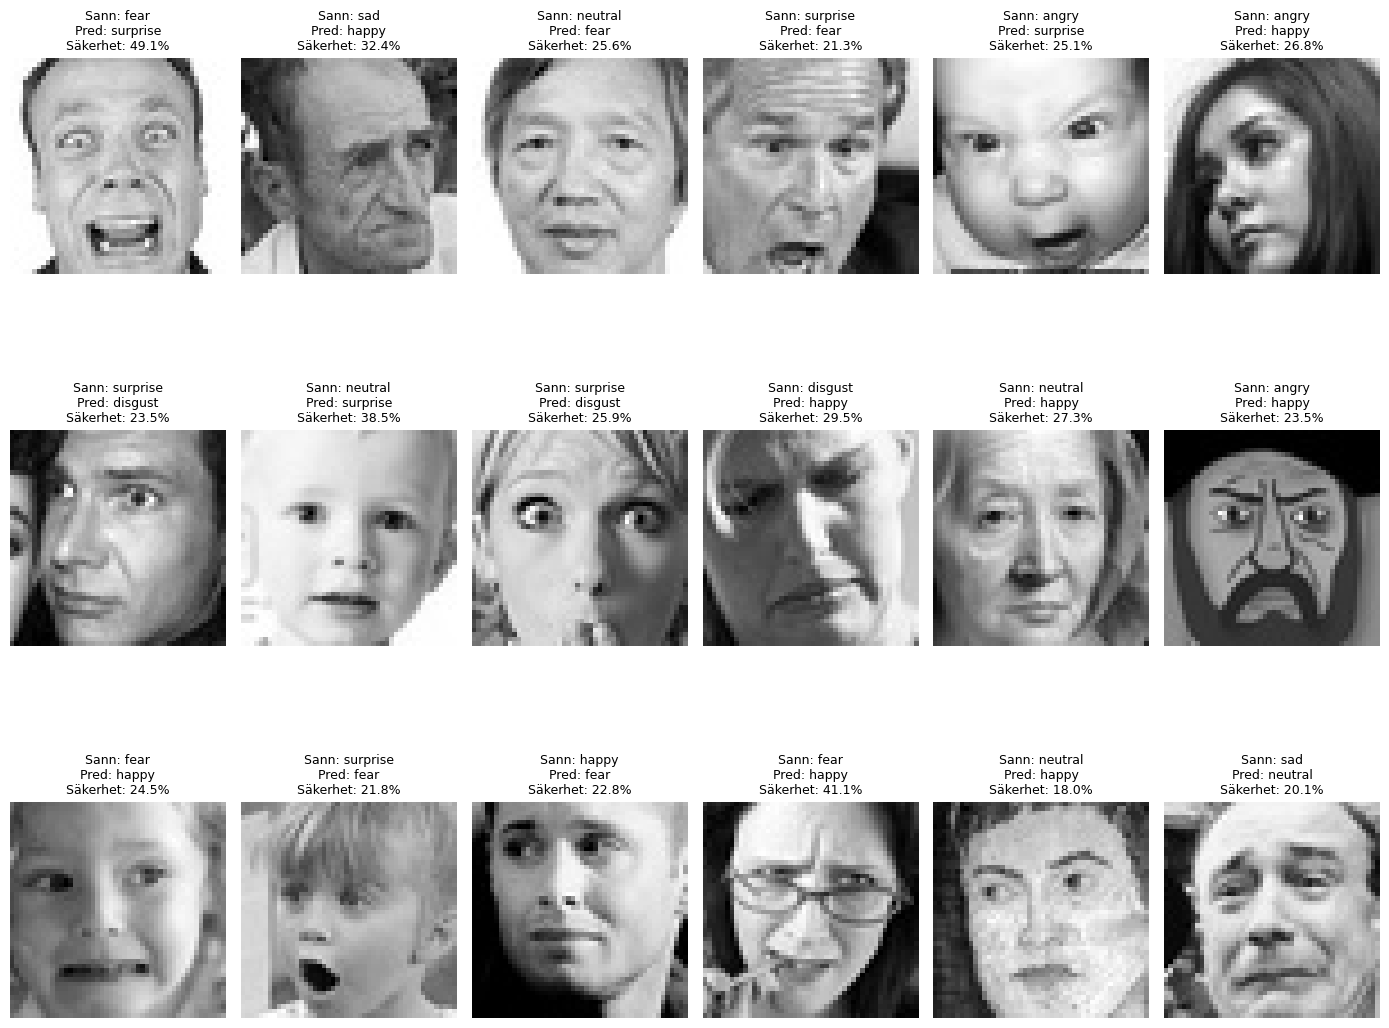

In [26]:
plot_misclassified_examples(
    val_images_norm,
    val_labels,
    baseline_val_pred,
    baseline_val_proba,
    class_names,
    n_images=18,
    random_state=42
)

De felklassificerade bilderna visar att modellen ofta blandar ihop uttryck som liknar varandra, till exempel `fear`, `surprise`, `sad` och `neutral`. Vissa fel är förståeliga eftersom bilderna är lågupplösta eller otydliga, men modellen missar även uttryck som verkar tydliga med blott öga. Det är rimligt för en enkel baseline-modell tränad på ett begränsat subset, eftersom modellen bara lär sig pixelmönster och inte tolkar ansiktsuttryck på samma sätt som en människa.

In [36]:
# Utvärderar baseline- modellen på testdata

baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(
    test_images_norm,
    test_labels,
    verbose=0
)

print(f"Baseline test loss: {baseline_test_loss:.4f}")
print(f"Baseline test accuracy: {baseline_test_accuracy:.4f}")

Baseline test loss: 1.7458
Baseline test accuracy: 0.3306


## 6) Gör prediktioner på ny data

### Förbättrad modell :

In [28]:
def build_and_compile_improved_model():
    """
    Bygger en förbättrad CNN-modell med fler convolutional layers och dropout.
    Dropout används för att minska risken för overfitting.
    """

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    model = keras.Sequential([

        layers.Input(shape=(48, 48, 1)),

        # Block 1
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            activation="relu",
            padding="same"
        ),
        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            padding="same"
        ),
        layers.Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.30),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.50),

        layers.Dense(7, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model

In [29]:
model_2_improved = build_and_compile_improved_model()
model_2_improved.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,245,671 (4.75 MB)

 Trainable params: 1,245,671 (4.75 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
def apply_early_stopping():
    """
    Stoppar träningen när val_loss inte förbättras.
    Återställer automatiskt de bästa vikterna.
    """

    return keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        min_delta=0.001
    )

In [31]:
def train_model(model, model_name="model", epochs=20, batch_size=32):
    """
    Tränar en modell med vald epochs och batch_size.
    """

    print(f"Träning av {model_name}: epochs = {epochs}, batch_size = {batch_size}")

    history = model.fit(
        train_images_norm,
        train_labels,
        validation_data=(val_images_norm, val_labels),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[apply_early_stopping()]
    )

    best_epoch = np.argmin(history.history["val_loss"]) + 1
    val_loss, val_accuracy = model.evaluate(
        val_images_norm,
        val_labels,
        verbose=0
    )

    print(f"\nBästa resultat för {model_name}:")
    print(f"Bästa epoch:  {best_epoch}")
    print(f"Val accuracy: {val_accuracy:.4f}")
    print(f"Val loss:     {val_loss:.4f}")

    return history

In [ ]:
# tränar förbättrad modell:

history_model_2 = train_model(
    model_2_improved,
    model_name="model_2_improved",
    epochs=20,
    batch_size=32
)

Träning av model_2_improved: epochs = 20, batch_size = 32
Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - accuracy: 0.1348 - loss: 1.9511 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.1464 - loss: 1.9463 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 155ms/step - accuracy: 0.1379 - loss: 1.9461 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.1330 - loss: 1.9463 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 151ms/step - accuracy: 0.1420 - loss: 1.9462 - val_accuracy: 0.1429 - val_loss: 1.9459
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 0.1379 - loss: 1.9463 - val_accuracy: 0.1429 - val_loss: 1.9459

Bästa resultat för model_2_improved:
Bästa epoch:  1
Val accuracy: 0.1429
Val loss:     1.9459


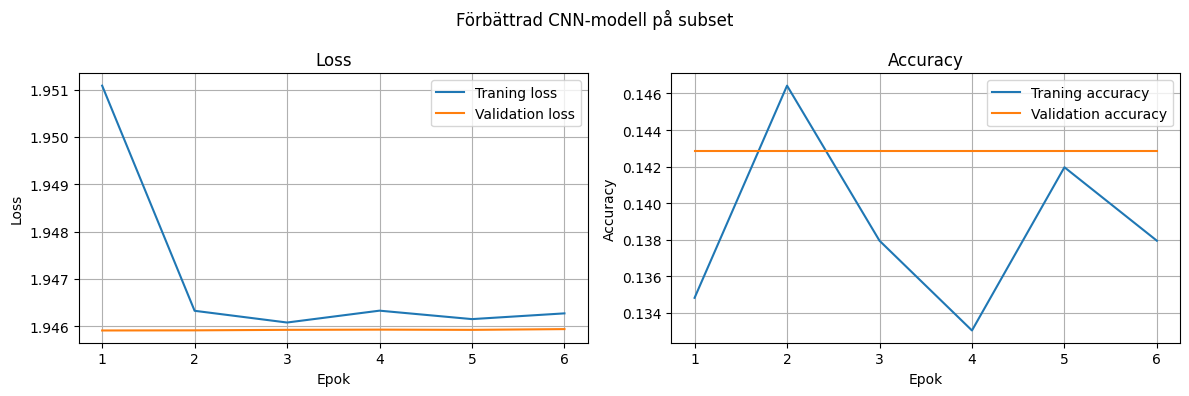

In [33]:
plot_history(history_model_2, title="Förbättrad CNN-modell på subset")

In [34]:
# Utvärderar förbättrad modell på min testdata:

model_2_test_loss, model_2_test_accuracy = model_2_improved.evaluate(
    test_images_norm,
    test_labels,
    verbose=0
)

print(f"Model 2 test loss: {model_2_test_loss:.4f}")
print(f"Model 2 test accuracy: {model_2_test_accuracy:.4f}")

Model 2 test loss: 1.9461
Model 2 test accuracy: 0.1737


In [37]:
# jämför baseline och förbättrad modell:

comparison_results = pd.DataFrame({
    "model": ["Baseline CNN", "Improved CNN"],
    "test_loss": [baseline_test_loss, model_2_test_loss],
    "test_accuracy": [baseline_test_accuracy, model_2_test_accuracy]
})

comparison_results

,model,test_loss,test_accuracy
0,Baseline CNN,1.745762,0.330593
1,Improved CNN,1.946107,0.173725


Baseline-modellen jämfördes med en förbättrad CNN-modell. Jag försökte se om fler convolutional layers, dropout och early stopping kunde förbättra resultatet och minska risken för overfitting.

**Baseline modellen presterade bättre** än den förbättrade modellen på testdatan. Baseline CNN fick en **test accuracy på cirka 0.33**, medan Improved CNN endast fick cirka 0.17. **Baseline-modellen hade även lägre test loss**. Detta tyder på att den förbättrade modellen inte generaliserade bättre, trots att den hade fler lager och dropout. En möjlig förklaring är att den förbättrade modellen blev för komplex i förhållande till det begränsade träningssubsetet, eller att den hade behövt mer data, fler epoker eller justerade hyperparametrar.

## 6) Gör prediktioner på ny data

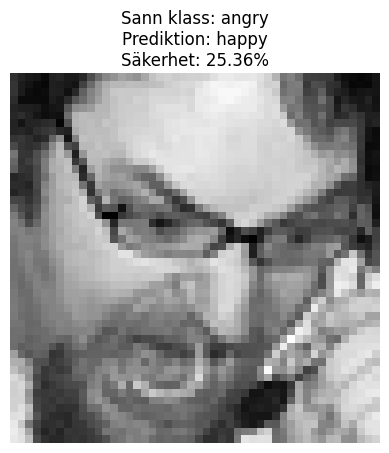

In [38]:
# Prediktion på en enskild bild från testdatan

image_index = 0

image = test_images_norm[image_index]
true_label = test_labels[image_index]

image_for_prediction = np.expand_dims(image, axis=0)

prediction = baseline_model.predict(image_for_prediction, verbose=0)
predicted_label = np.argmax(prediction)
confidence = np.max(prediction)

plt.imshow(image.squeeze(), cmap="gray")
plt.axis("off")
plt.title(
    f"Sann klass: {class_names[true_label]}\n"
    f"Prediktion: {class_names[predicted_label]}\n"
    f"Säkerhet: {confidence:.2%}"
)
plt.show()

Det viktiga enligt mig är att 25.36% säkerheten är låg. Det betyder att modellen inte är särskilt säker på sin prediktion, som i det här fallet blev fel predikterad på den enskilda testbilden. 
Allt det här stämmer överens med modellens test accuracy på cirka 0.33 och visar att modellen fortfarande har svårt att generalisera till ny data.

## 7) Analysera resultatet

1. Modellen fungerar till viss del, men resultatet är ganska begränsat. Baseline-modellen fick en test accuracy på cirka 0.33, vilket betyder att modellen klassificerar ungefär en tredjedel av testbilderna rätt. Eftersom det finns 7 olika klasser är detta bättre än ren slump, men fortfarande inte ett särskilt starkt resultat.

2. Under träningen såg jag att training accuracy ökade och att training loss minskade. Det betyder att modellen lärde sig något från träningsdatan. Validation accuracy ökade också, men låg hela tiden lägre än training accuracy. Det visar att modellen hade svårare att prestera på data som den inte tränades direkt på.

3. Det finns vissa tecken på overfitting. Modellen presterar bättre på träningsdatan än på validation- och testdatan. Det betyder att modellen delvis lär sig mönster i träningsdatan, men har svårare att generalisera till nya bilder. Samtidigt är modellen inte extremt övertränad, eftersom validation accuracy ändå ökade under träningen.

4. Confusion matrixen visade att modellen klarade vissa klasser bättre än andra. Den hade lättast för till exempel `surprise` och `disgust`, medan klasser som `sad`, `angry`, `fear` och `neutral` var svårare. Dessa uttryck blandades ofta ihop med andra klasser. Det kan bero på att vissa ansiktsuttryck liknar varandra, särskilt i små gråskalebilder.

5. Jag testade också en förbättrad CNN-modell med fler lager, dropout och early stopping. Den modellen blev däremot inte bättre än baseline-modellen. Baseline CNN fick högre test accuracy och lägre test loss. Det visar att en mer avancerad modell inte automatiskt ger bättre resultat. Den förbättrade modellen kan ha varit för komplex i förhållande till det begränsade subsetet, eller så hade den behövt mer data och mer justering.

6. Det som verkar påverka resultatet mest är att bilderna är små, bara 48x48 pixlar, och att ansiktsuttryck kan vara svåra att skilja åt. En annan faktor är att jag tränade modellen på ett mindre balanserat subset med 400 bilder per klass. Det gjorde träningen snabbare och mer hanterbar, men modellen fick också mindre data att lära sig från.

7. En begränsning med modellen är att den är ganska enkel och inte använder hela träningsdatan. Den använder inte heller data augmentation, vilket hade kunnat hjälpa modellen att hantera variationer i ansiktsvinkel, ljus och bildkvalitet. Modellen kan därför användas som en första baseline, men den behöver förbättras för att ge mer pålitliga prediktioner.

## 8) Reflektion